In [8]:
import requests
import pandas as pd


def get_weather_forecast_dataframe(
    start_date,
    end_date,
    latitude,
    longitude
):
    """
    Fetch real forecast weather data from Open-Meteo API
    and return dataframe with:
    time, tavg, tmin, tmax, prcp, wspd, pres
    """

    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": latitude,
        "longitude": longitude,

        # Daily weather variables
        "daily": [
            "temperature_2m_mean",
            "temperature_2m_min",
            "temperature_2m_max",
            "precipitation_sum",
            "wind_speed_10m_max",
            "surface_pressure_mean"
        ],

        "timezone": "auto",
        "start_date": start_date,
        "end_date": end_date
    }

    response = requests.get(url, params=params)

    # Raise error if API failed
    response.raise_for_status()

    data = response.json()

    # Create dataframe
    weather_forecast_df = pd.DataFrame({
        "time": pd.to_datetime(data["daily"]["time"]),

        "tavg": data["daily"]["temperature_2m_mean"],

        "tmin": data["daily"]["temperature_2m_min"],

        "tmax": data["daily"]["temperature_2m_max"],

        "prcp": data["daily"]["precipitation_sum"],

        "wspd": data["daily"]["wind_speed_10m_max"],

        "pres": data["daily"]["surface_pressure_mean"]
    })

    return weather_forecast_df

In [9]:
from datetime import datetime
current_date = datetime.now().strftime('%Y-%m-%d')
prediction_date = "2026-05-15"
weather_forecast_df = get_weather_forecast_dataframe(
    start_date= current_date,
    end_date=prediction_date,

    # Abha coordinates
    latitude=18.2164,
    longitude=42.5053
)

print(weather_forecast_df.head(20))

        time  tavg  tmin  tmax  prcp  wspd   pres
0 2026-05-10  20.2  15.3  26.6   0.0  23.0  790.3
1 2026-05-11  20.8  16.0  26.8   0.0  15.1  790.7
2 2026-05-12  21.4  16.9  27.7   0.0  13.2  790.2
3 2026-05-13  21.6  17.0  26.4   0.2  14.6  788.8
4 2026-05-14  22.6  17.9  28.2   0.0  14.2  788.7
5 2026-05-15  23.2  17.9  27.7   0.0  15.2  788.8


Last dataset date: 2025-12-31 00:00:00


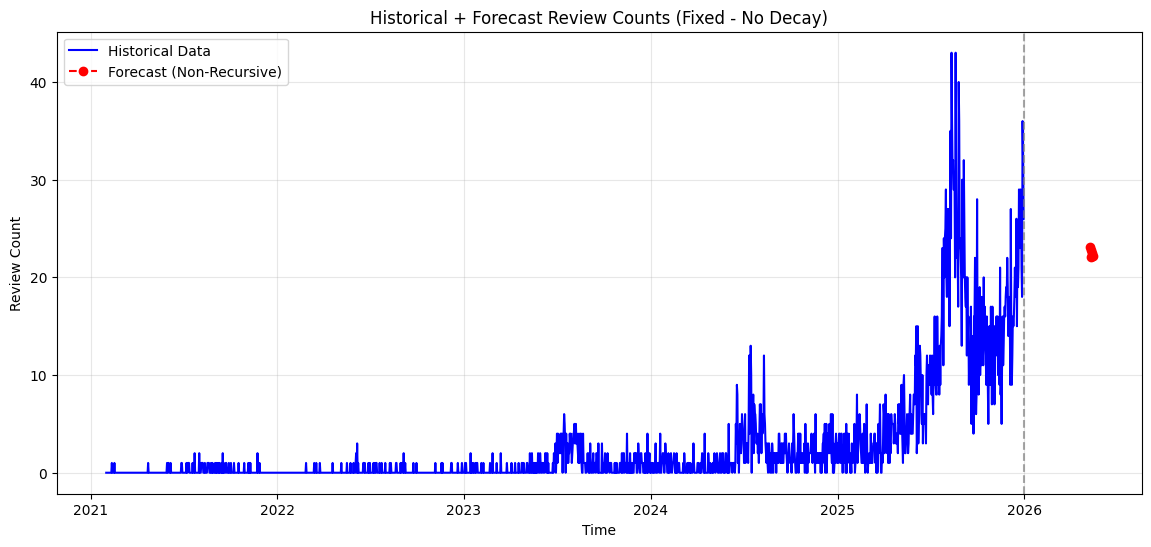


--- Diagnostic Information ---
Historical mean: 2.79
Historical std: 5.80
Forecast mean: 22.47
Forecast std: 0.38
Forecast min: 22.13
Forecast max: 23.06

--- Forecast Results ---
        time  prediction
0 2026-05-10   23.064817
1 2026-05-11   22.754229
2 2026-05-12   22.127421
3 2026-05-13   22.508638
4 2026-05-14   22.158242
5 2026-05-15   22.187850


In [10]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



loaded_model = lgb.Booster(
    model_file='lgbm_review_count_model.txt'
)



features = [
    'tavg', 'tmin', 'tmax',
    'prcp', 'wspd', 'pres',

    'lag1', 'lag2', 'lag3',
    'lag7', 'lag14', 'lag30',

    'rolling_mean_7',
    'rolling_std_7',
    'rolling_max_7',

    'rolling_mean_14',
    'rolling_std_14',
    'rolling_max_14',

    'rolling_mean_30',
    'rolling_std_30',
    'rolling_max_30'
]



def forecast_until_date(
    need_to_date,
    weather_forecast_df,
    csv_path='merged_weather_reviews.csv'
):

    # Load historical data
    merged_data = pd.read_csv(csv_path)
    merged_data['time'] = pd.to_datetime(merged_data['time'])
    merged_data = merged_data.sort_values('time')

    if len(merged_data) < 30:
        raise ValueError("Dataset must contain at least 30 rows")

    last_dataset_date = merged_data['time'].max()
    print(f"Last dataset date: {last_dataset_date}")

    # Prepare weather forecast data
    weather_forecast_df['time'] = pd.to_datetime(weather_forecast_df['time'])
    need_to_date = pd.to_datetime(need_to_date)

    weather_forecast_df = weather_forecast_df[
        (weather_forecast_df['time'] > last_dataset_date) & 
        (weather_forecast_df['time'] <= need_to_date)
    ].sort_values('time')

    # CRITICAL FIX: Use ONLY historical data for all predictions
    # No recursive updates - each prediction uses the same historical features
    predictions = []
    
    # Pre-compute all historical features once
    historical_data = merged_data.copy()
    
    # Add lag features to historical data
    historical_data['lag1'] = historical_data['review_count'].shift(1)
    historical_data['lag2'] = historical_data['review_count'].shift(2)
    historical_data['lag3'] = historical_data['review_count'].shift(3)
    historical_data['lag7'] = historical_data['review_count'].shift(7)
    historical_data['lag14'] = historical_data['review_count'].shift(14)
    historical_data['lag30'] = historical_data['review_count'].shift(30)
    
    # Add rolling features to historical data
    historical_data['rolling_mean_7'] = historical_data['review_count'].rolling(7).mean()
    historical_data['rolling_std_7'] = historical_data['review_count'].rolling(7).std()
    historical_data['rolling_max_7'] = historical_data['review_count'].rolling(7).max()
    
    historical_data['rolling_mean_14'] = historical_data['review_count'].rolling(14).mean()
    historical_data['rolling_std_14'] = historical_data['review_count'].rolling(14).std()
    historical_data['rolling_max_14'] = historical_data['review_count'].rolling(14).max()
    
    historical_data['rolling_mean_30'] = historical_data['review_count'].rolling(30).mean()
    historical_data['rolling_std_30'] = historical_data['review_count'].rolling(30).std()
    historical_data['rolling_max_30'] = historical_data['review_count'].rolling(30).max()
    
    # Use the last row of historical data as the base for all predictions
    base_features = historical_data.iloc[-1][features].to_dict()
    
    for _, weather_row in weather_forecast_df.iterrows():
        # Create input row using historical features + current weather
        input_row = pd.DataFrame([{
            # Weather features (current forecast)
            'tavg': weather_row['tavg'],
            'tmin': weather_row['tmin'],
            'tmax': weather_row['tmax'],
            'prcp': weather_row['prcp'],
            'wspd': weather_row['wspd'],
            'pres': weather_row['pres'],
            
            # Lag features (from last historical data point)
            'lag1': base_features['lag1'],
            'lag2': base_features['lag2'],
            'lag3': base_features['lag3'],
            'lag7': base_features['lag7'],
            'lag14': base_features['lag14'],
            'lag30': base_features['lag30'],
            
            # Rolling features (from last historical data point)
            'rolling_mean_7': base_features['rolling_mean_7'],
            'rolling_std_7': base_features['rolling_std_7'],
            'rolling_max_7': base_features['rolling_max_7'],
            
            'rolling_mean_14': base_features['rolling_mean_14'],
            'rolling_std_14': base_features['rolling_std_14'],
            'rolling_max_14': base_features['rolling_max_14'],
            
            'rolling_mean_30': base_features['rolling_mean_30'],
            'rolling_std_30': base_features['rolling_std_30'],
            'rolling_max_30': base_features['rolling_max_30']
        }])
        
        input_row = input_row[features]
        
        # Make prediction
        pred_log = loaded_model.predict(input_row)
        pred = np.expm1(pred_log)[0]
        
        predictions.append({
            'time': weather_row['time'],
            'prediction': pred
        })
    
    pred_df = pd.DataFrame(predictions)
    
    # Visualization
    plt.figure(figsize=(14, 6))
    
    plt.plot(
        merged_data['time'],
        merged_data['review_count'],
        label='Historical Data',
        color='blue'
    )
    
    plt.plot(
        pred_df['time'],
        pred_df['prediction'],
        label='Forecast (Non-Recursive)',
        color='red',
        marker='o',
        linestyle='--'
    )
    
    plt.axvline(x=last_dataset_date, linestyle='--', color='gray', alpha=0.7)
    
    plt.xlabel('Time')
    plt.ylabel('Review Count')
    plt.title('Historical + Forecast Review Counts (Fixed - No Decay)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.show()
    
    # Print diagnostic information
    print(f"\n--- Diagnostic Information ---")
    print(f"Historical mean: {merged_data['review_count'].mean():.2f}")
    print(f"Historical std: {merged_data['review_count'].std():.2f}")
    print(f"Forecast mean: {pred_df['prediction'].mean():.2f}")
    print(f"Forecast std: {pred_df['prediction'].std():.2f}")
    print(f"Forecast min: {pred_df['prediction'].min():.2f}")
    print(f"Forecast max: {pred_df['prediction'].max():.2f}")
    
    return pred_df


# For comparison, here's an ALTERNATIVE approach using difference-based prediction
# (Uncomment to use this instead)
def forecast_until_date_diff_based(
    need_to_date,
    weather_forecast_df,
    csv_path='merged_weather_reviews.csv'
):
    """
    Alternative: Predict the difference instead of absolute values
    This can be more stable for time series forecasting
    """
    merged_data = pd.read_csv(csv_path)
    merged_data['time'] = pd.to_datetime(merged_data['time'])
    merged_data = merged_data.sort_values('time')
    
    # Calculate differences
    merged_data['diff'] = merged_data['review_count'].diff()
    merged_data['pct_change'] = merged_data['review_count'].pct_change()
    
    if len(merged_data) < 30:
        raise ValueError("Dataset must contain at least 30 rows")
    
    last_dataset_date = merged_data['time'].max()
    print(f"Last dataset date: {last_dataset_date}")
    
    weather_forecast_df['time'] = pd.to_datetime(weather_forecast_df['time'])
    need_to_date = pd.to_datetime(need_to_date)
    
    weather_forecast_df = weather_forecast_df[
        (weather_forecast_df['time'] > last_dataset_date) & 
        (weather_forecast_df['time'] <= need_to_date)
    ].sort_values('time')
    
    predictions = []
    current_value = merged_data['review_count'].iloc[-1]
    
    # Pre-compute features (excluding diff/pct_change from features)
    base_features = {}
    for feat in features:
        if feat in merged_data.columns:
            base_features[feat] = merged_data[feat].iloc[-1]
    
    for _, weather_row in weather_forecast_df.iterrows():
        input_row = pd.DataFrame([{
            **{feat: base_features[feat] for feat in features if feat in base_features},
            'tavg': weather_row['tavg'],
            'tmin': weather_row['tmin'],
            'tmax': weather_row['tmax'],
            'prcp': weather_row['prcp'],
            'wspd': weather_row['wspd'],
            'pres': weather_row['pres'],
        }])
        
        input_row = input_row[features]
        
        # Predict the difference
        pred_diff_log = loaded_model.predict(input_row)
        pred_diff = np.expm1(pred_diff_log)[0]
        
        # Update current value
        current_value += pred_diff
        
        predictions.append({
            'time': weather_row['time'],
            'prediction': current_value
        })
    
    return pd.DataFrame(predictions)


# Run the fixed version
forecast_df = forecast_until_date(
    need_to_date=prediction_date,
    weather_forecast_df=weather_forecast_df,
    csv_path='merged_weather_reviews.csv'
)

print("\n--- Forecast Results ---")
print(forecast_df)

# #Optional: Compare with difference-based approach
# forecast_df_diff = forecast_until_date_diff_based(
#     need_to_date=prediction_date,
#     weather_forecast_df=weather_forecast_df,
#     csv_path='merged_weather_reviews.csv'
# )
# print("\n--- Difference-Based Forecast ---")
# print(forecast_df_diff)